In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpm
import statistics

<b>Message: </b> <br>
Data Task Force (DTF) was approached by an organization wanting to start a streaming service. They are considering if they should include film, tv, and non-English films and tv for their service. DTF pulled the three datasets from Netflix to analyze global, country, and most popular streamed. Once our analysis is completed, we will be able to provide options if having all options available or if they should consolidate their streaming films and tv shows. <br>

<b>Medium:</b><br>
For the medium, the initial work will be completed in Jupyter lab to compile and analyze the data. Once completed, the graphs will be moved  to an infographic to display each graph. This allows the audience to see how each category fairs against the others.<br>

<b>Design:</b><br>
For the design, the categories, ranks, and numerical variables were considered. Since rank had multiple top ten based on categories, it is important that they were separated by color and category. The text and sizing were kept the same so that no graph took more space and presented a bias. Overall, the graphs used were to ensure that each section is provided with their information in the appropriate manner. <br>

<b>Ethical:</b><br>
 For our ethical considerations, we ensured that we did not remove data that could potentially skew the results. The data had different column variables for each dataset, so the most common factors were used to have a fair compare. The data is filtered with labeling and recycled within the datasets. The data source is credibility as it came directly from Netflix’s website. The data is open source, so it considered acquired in an ethical way. If there were any ethical implications, I would ensure to contact the owners of the data or find open-source data that is comparable to the originally anticipated one. <br>


In [165]:
    country_xl = 'all-weeks-countries-netflix.xlsx'
    week_xl = 'all-weeks-global-netflix.xlsx'
    pop_xl = 'most-popular-netflix.xlsx'
    week_ctry = pd.read_excel(country_xl, index_col = 0) 
    week_glob = pd.read_excel(week_xl)
    most_pop =  pd.read_excel(pop_xl)

C:\Users\golde\DSC\envs\book_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\golde\DSC\envs\book_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\golde\DSC\envs\book_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


### Weekly Country ###

In [166]:
ctsort = week_ctry.sort_values(by='cumulative_weeks_in_top_10', ascending = False)
ctsorted = ctsort.drop('season_title', axis = 1)
#https://www.geeksforgeeks.org/python/how-to-drop-one-or-multiple-columns-in-pandas-dataframe/
ctsorted.groupby(['show_title', 'week']).sum()
ctsorted.head()


,country_iso2,week,category,weekly_rank,show_title,cumulative_weeks_in_top_10
country_name,,,,,,
Pakistan,PK,2024-02-25,TV,9,Money Heist,113
Pakistan,PK,2024-02-18,TV,7,Money Heist,112
Pakistan,PK,2024-02-11,TV,7,Money Heist,111
Pakistan,PK,2024-02-04,TV,8,Money Heist,110
Pakistan,PK,2024-01-28,TV,6,Money Heist,109


In [167]:
ctsorted['max'] = ctsorted.groupby('country_iso2')['cumulative_weeks_in_top_10'].transform('max')

In [168]:
ctmax = ctsorted.sort_values('max', ascending = False).drop_duplicates('country_iso2')

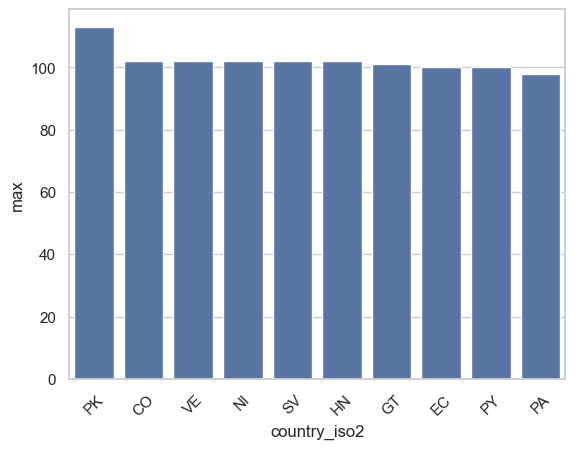

In [169]:
sns.barplot(x = 'country_iso2', y = 'max', data = ctmax.head(10));
plt.xticks(rotation =45);
#https://www.geeksforgeeks.org/data-visualization/seaborn-barplot-method-in-python/ 
# https://medium.com/@arsalan_zafar/bar-plots-in-seaborn-6a81c453e0c4

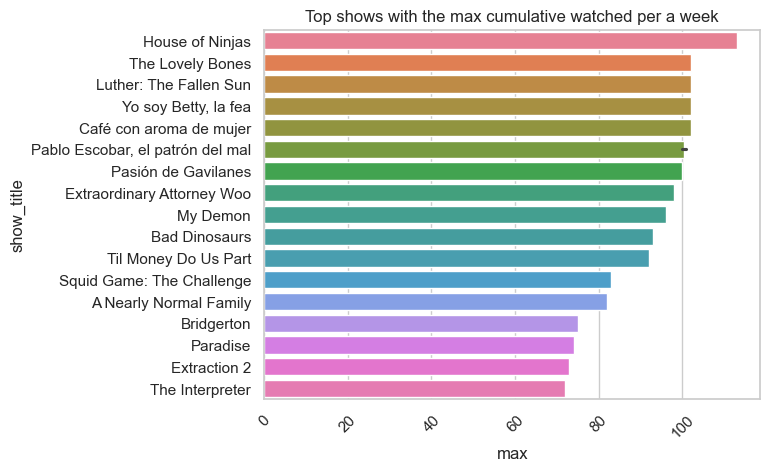

In [170]:
sns.barplot(x = 'max', y = 'show_title', hue = 'show_title' , data = ctmax.head(20));
plt.title("Top shows with the max cumulative watched per a week")
plt.xticks(rotation =45);

### Weekly Global ###

In [171]:
wksort = week_glob.drop(['season_title' , 'is_staggered_launch', 'episode_launch_details'], axis = 1)
wks = wksort.groupby(['show_title', 'weekly_views']).sum()

wksres = pd.DataFrame(wks)
wksres.reset_index(drop = False, inplace = True)

#https://www.geeksforgeeks.org/python/reset-index-in-pandas-dataframe/ 

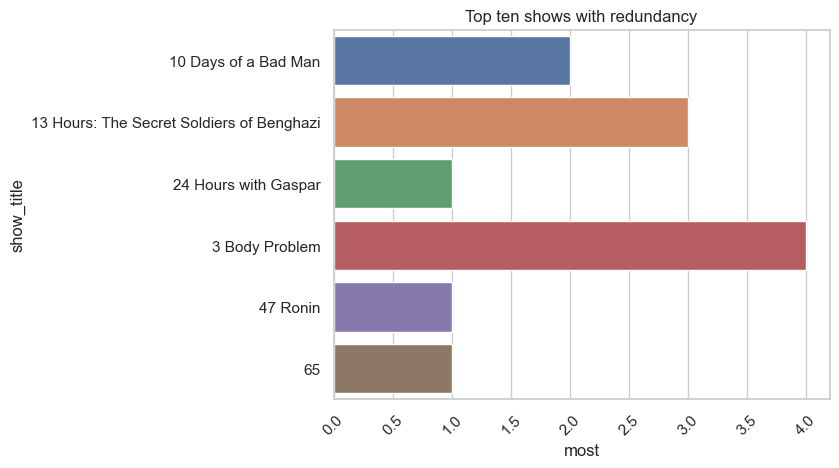

In [172]:
wksres['most'] = wksres.groupby('show_title')['cumulative_weeks_in_top_10'].transform('max')
wksres.sort_values(by="weekly_hours_viewed", ascending=False)

sns.barplot(x = 'most', y = 'show_title', hue = 'show_title' , data = wksres.head(10));
plt.title("Top ten shows with redundancy")
plt.xticks(rotation =45);

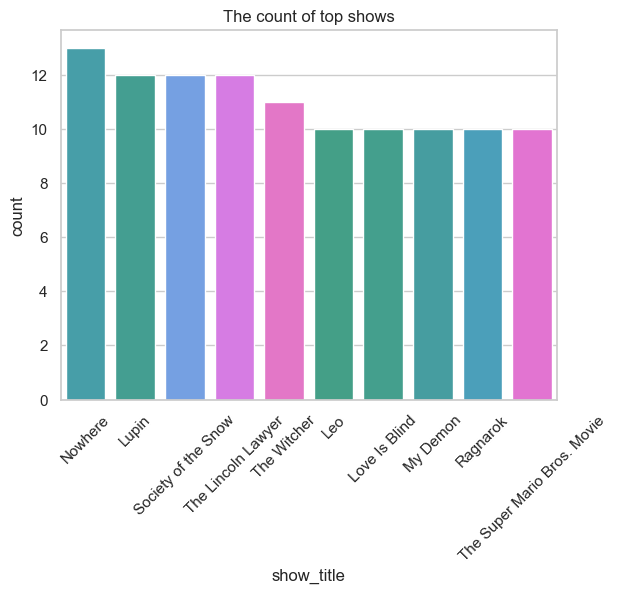

In [173]:
top10 = wksres['show_title'].value_counts().iloc[:10].index
sns.countplot(data = wksres, x = 'show_title', hue = 'show_title', order = top10);
plt.title("The count of top shows")
plt.xticks(rotation =45);

#google ai assist by using pandas_values_counts via pandas site

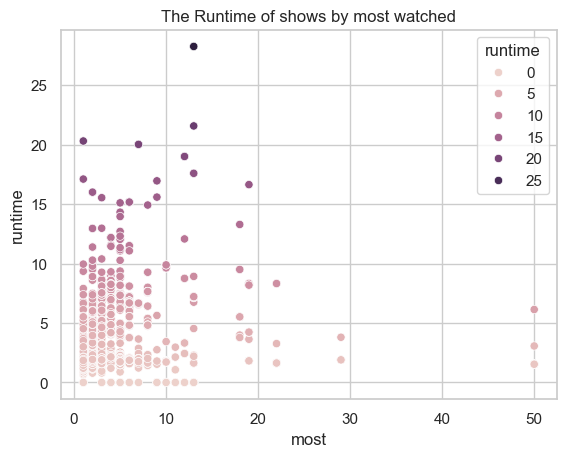

In [174]:
sns.set(style = 'whitegrid')
sns.scatterplot(x='most', y='runtime', hue = 'runtime', data = wksres)
plt.title('The Runtime of shows by most watched')
plt.show()

### Most Popular ###

In [175]:
popsort = most_pop.drop(['season_title' , 'hours_viewed_first_91_days'], axis = 1)
pops = popsort.groupby(['show_title', 'rank']).sum()

popres = pd.DataFrame(pops)
popres.reset_index(drop = False, inplace = True)
pop3 = popres.sort_values(by = ['category' ,'rank'], ascending = [True, True])

#google ai assist to group by category then ascend by rank

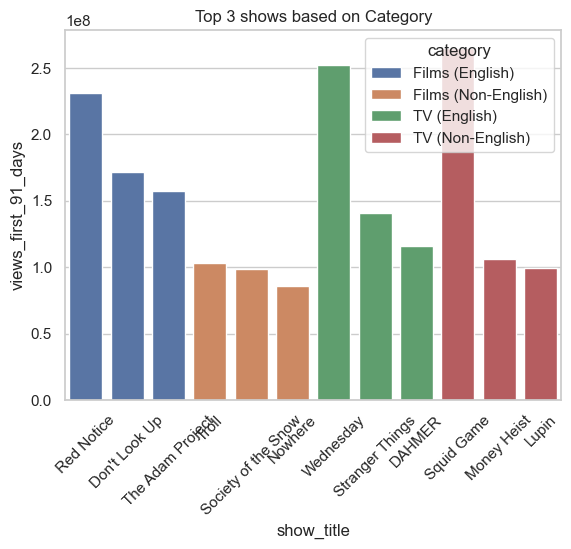

In [176]:
top3 = pop3.groupby('category').head(3).reset_index(drop=True)
sns.barplot(data = top3, x = 'show_title', y='views_first_91_days', hue = 'category');
plt.title("Top 3 shows based on Category")
plt.xticks(rotation =45);

#https://www.geeksforgeeks.org/python/how-to-show-values-on-seaborn-barplot/

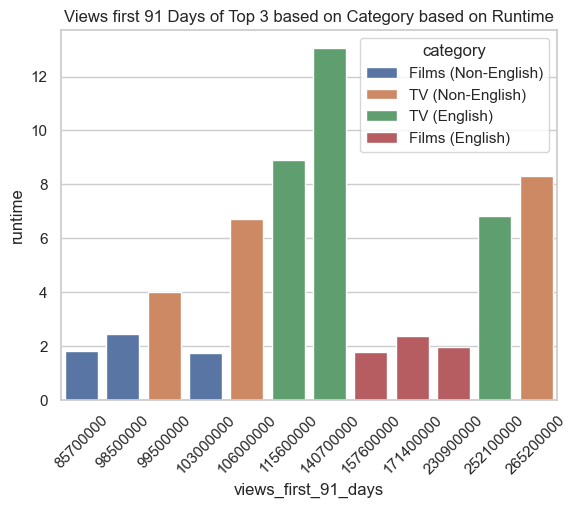

In [177]:
#barplot
sns.set(style='whitegrid');
sns.barplot(x='views_first_91_days', y='runtime', hue = 'category', data = top3);
plt.title("Views first 91 Days of Top 3 based on Category based on Runtime")
plt.xticks(rotation =45);